After understanding and downloading the data, now I will understand how the data works, check some plots on the data, how balanced it is, main features, outliers, biased data, unethical data and features that can be dropped off.

## Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1
from pathlib import Path

## Loading Events Calendar

In [9]:
project_root=Path.cwd()
if project_root.name=="notebooks":
    project_root=project_root.parent
events=pd.read_csv(
    project_root / "data" / "events_2022_2025.csv",
    parse_dates=["EventDate"]
)

events[["Season", "RoundNumber", "EventDate", "EventName"]]

,Season,RoundNumber,EventDate,EventName
0,2022,1,2022-03-20,Bahrain Grand Prix
1,2022,2,2022-03-27,Saudi Arabian Grand Prix
2,2022,3,2022-04-10,Australian Grand Prix
3,2022,4,2022-04-24,Emilia Romagna Grand Prix
4,2022,5,2022-05-08,Miami Grand Prix
...,...,...,...,...
87,2025,20,2025-10-26,Mexico City Grand Prix
88,2025,21,2025-11-09,São Paulo Grand Prix
89,2025,22,2025-11-22,Las Vegas Grand Prix
90,2025,23,2025-11-30,Qatar Grand Prix


## Loading all race laps

In [ ]:
all_laps=[]
failed_events=[]

for _, event in events.iterrows():
    year=int(event["Season"])
    round_number=int(event["RoundNumber"])
    print(f"Loading {year} - {event["EventName"]}")

    try:
        session=fastf1.get_session(year, round_number, "R")
        session.load(telemetry=False)
        race_laps=session.laps.copy()

        if race_laps.empty:
            raise ValueError("No lap data")

        race_laps["Season"]=year
        race_laps["RoundNumber"]=round_number
        race_laps["EventName"]=event["EventName"]
        all_laps.append(race_laps)

    except Exception as error:
        failed_events.append({
            "Season": year,
            "RoundNumber": round_number,
            "EventName": event["EventName"],
            "Error": str(error)
        })

req         WARNING 	DEFAULT CACHE ENABLED! (188.75 MB) C:\Users\Francisco\AppData\Local\Temp\fastf1


Loading 2022 - Bahrain Grand Prix


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand P

Loading 2022 - Saudi Arabian Grand Prix


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', '27', '18', '23', '77', '14', '3', '6', '22', '47']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using c

...

req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Driver 20: Encountered 1 timing

Loading 2023 - British Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

Loading 2023 - Hungarian Grand Prix


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...


## Event Coverage Across Seasons

In [ ]:
event_presence=pd.crosstab(
    events["EventName"],
    events["Season"]
)

event_presence=event_presence.reindex(
    columns=range(2022,2026),
    fill_value=0
).gt(0)

coverage=event_presence.copy()

coverage["MissingYears"]=event_presence.apply(
    lambda row: ",".join(
        str(year) for year in row.index if not row[year]
    ),
    axis=1
)

coverage

Season,2022,2023,2024,2025,MissingYears
EventName,,,,,
Abu Dhabi Grand Prix,True,True,True,True,
Australian Grand Prix,True,True,True,True,
Austrian Grand Prix,True,True,True,True,
Azerbaijan Grand Prix,True,True,True,True,
Bahrain Grand Prix,True,True,True,True,
Belgian Grand Prix,True,True,True,True,
British Grand Prix,True,True,True,True,
Canadian Grand Prix,True,True,True,True,
Chinese Grand Prix,False,False,True,True,"2022,2023"


### Findings:

Of the 25 distinct Grand Prix events, 20 appear in all four seasons. The French Grand Prix appears only in 2022, limiting comparisons over time. All events remain in the general EDA, while comparisons across all four seasons can focus on recurring events.


## Checking if data from races was correctly downloaded

In [ ]:
laps=pd.concat(all_laps, ignore_index=True)
expected_events=events[
    ["Season", "EventName", "RoundNumber"]
].drop_duplicates()

loaded_events=laps[
    ["RoundNumber", "Season"]
].drop_duplicates()

In [ ]:
download_check=expected_events.merge(
    loaded_events,
    on=["Season", "RoundNumber"],
    how="left",
    indicator=True
)

missing_events=download_check.loc[
    download_check["_merge"]=="left_only"
]
missing_events

,Season,EventName,RoundNumber,_merge
2,2022,Australian Grand Prix,3,left_only
3,2022,Emilia Romagna Grand Prix,4,left_only
4,2022,Miami Grand Prix,5,left_only
5,2022,Spanish Grand Prix,6,left_only
6,2022,Monaco Grand Prix,7,left_only
...,...,...,...,...
87,2025,Mexico City Grand Prix,20,left_only
88,2025,São Paulo Grand Prix,21,left_only
89,2025,Las Vegas Grand Prix,22,left_only
90,2025,Qatar Grand Prix,23,left_only


# Part 2 - Working on race data (example)

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1
from pathlib import Path

## Loading Race Data

In [2]:
project_root=Path.cwd()

session=fastf1.get_session(2024, "Monza", "R")
session.load(telemetry=False)

race_laps=session.laps.copy()
race_laps["LapTimeSeconds"]=race_laps["LapTime"].dt.total_seconds()
csv_path=project_root / "data" / "monza_2024_race.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)
race_laps.to_csv(csv_path, index=False)

print(f"Saved Monza Race Data in {csv_path}")

req         WARNING 	DEFAULT CACHE ENABLED! (231.72 MB) C:\Users\Francisco\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


Saved Monza Race Data in c:\Users\Francisco\Desktop\Work\Semester 3\Practice Challenge\notebooks\data\monza_2024_race.csv


## Checking which drivers completed the race

In [3]:
session.results.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [4]:
#total number of laps is 53

session.results[["Abbreviation", "Status"]]

,Abbreviation,Status
16,LEC,Finished
81,PIA,Finished
4,NOR,Finished
55,SAI,Finished
44,HAM,Finished
1,VER,Finished
63,RUS,Finished
11,PER,Finished
23,ALB,Finished
20,MAG,Finished


In [5]:
race_laps=race_laps[race_laps["Driver"] !="TSU"]

## Lap time Evolution from three drivers (Linear Relationship check)

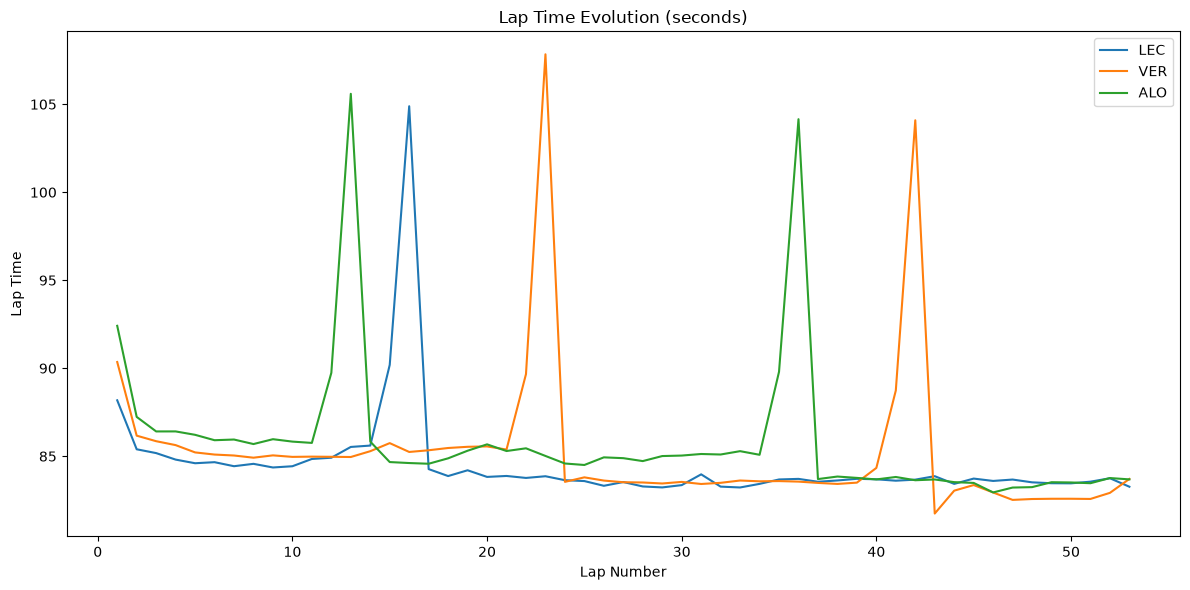

In [6]:
drivers=["LEC", "VER",  "ALO"]

plt.figure(figsize=(12,6))

for driver in drivers:
    driver_laps=race_laps[race_laps["Driver"]==driver]
    plt.plot(
        driver_laps["LapNumber"],
        driver_laps["LapTimeSeconds"],
        label=driver
    )

plt.xlabel("Lap Number")
plt.ylabel("Lap Time")
plt.title("Lap Time Evolution (seconds)")
plt.legend()
plt.tight_layout()
plt.show()


Observations:
The peaks of this plot showcase moments drivers went to the pits, making their lap times considerably higher.

## Check graph without pit laps

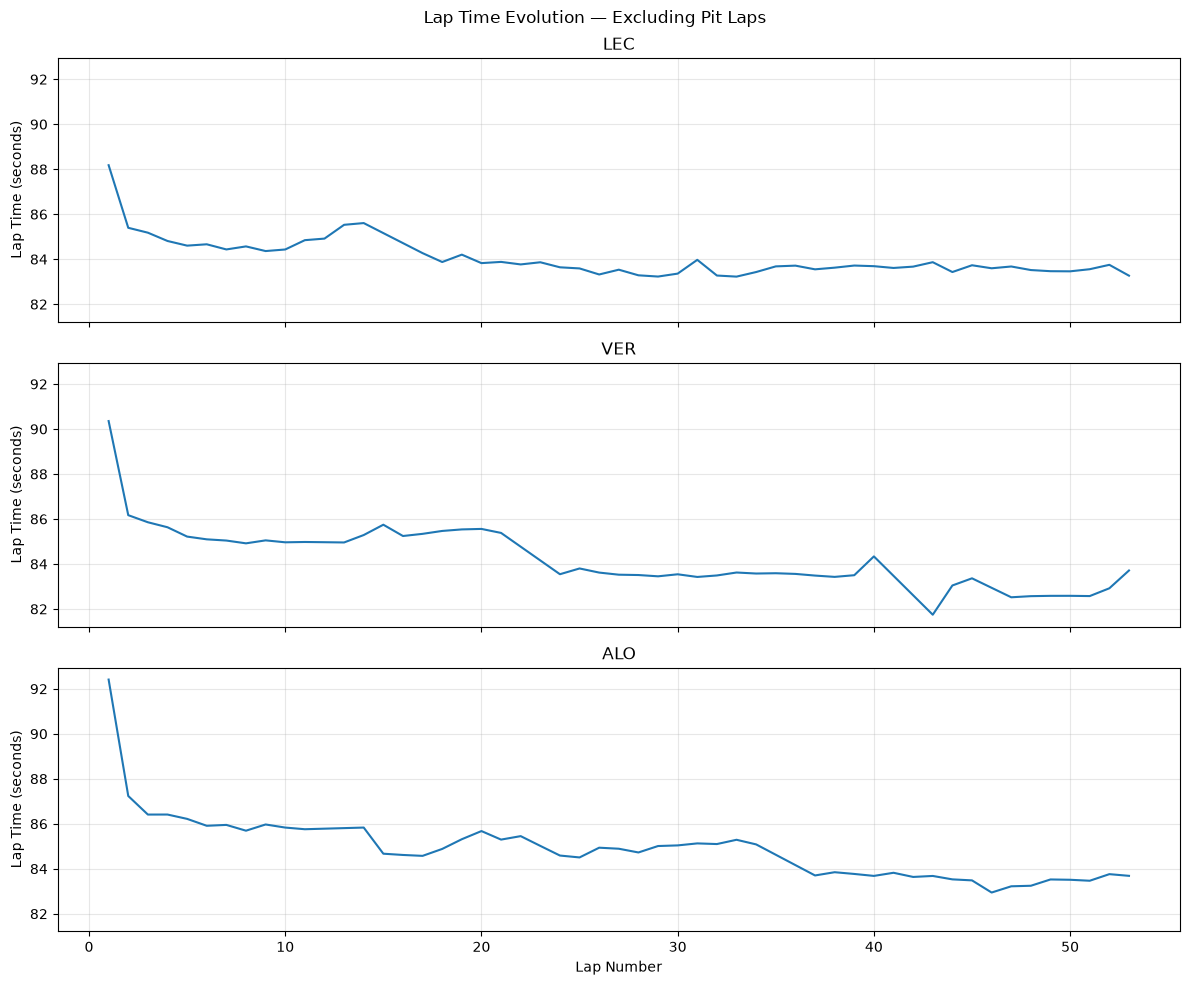

In [7]:
drivers = ["LEC", "VER", "ALO"]

fig, axes = plt.subplots(
    3, 1, figsize=(12, 10),
    sharex=True, sharey=True
)

for driver, ax in zip(drivers, axes):
    driver_laps = race_laps[
        (race_laps["Driver"] == driver)
        & race_laps["PitInTime"].isna()
        & race_laps["PitOutTime"].isna()
    ].sort_values("LapNumber")

    ax.plot(
        driver_laps["LapNumber"],
        driver_laps["LapTimeSeconds"]
    )

    ax.set_title(driver)
    ax.set_ylabel("Lap Time (seconds)")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Lap Number")
fig.suptitle("Lap Time Evolution — Excluding Pit Laps")
plt.tight_layout()
plt.show()

Observation:
It is a nonlinear relationship, since we can clearly see a downwards trend, however it tends to stabilize a lot after twentyish laps. 

## Tyre Degradation

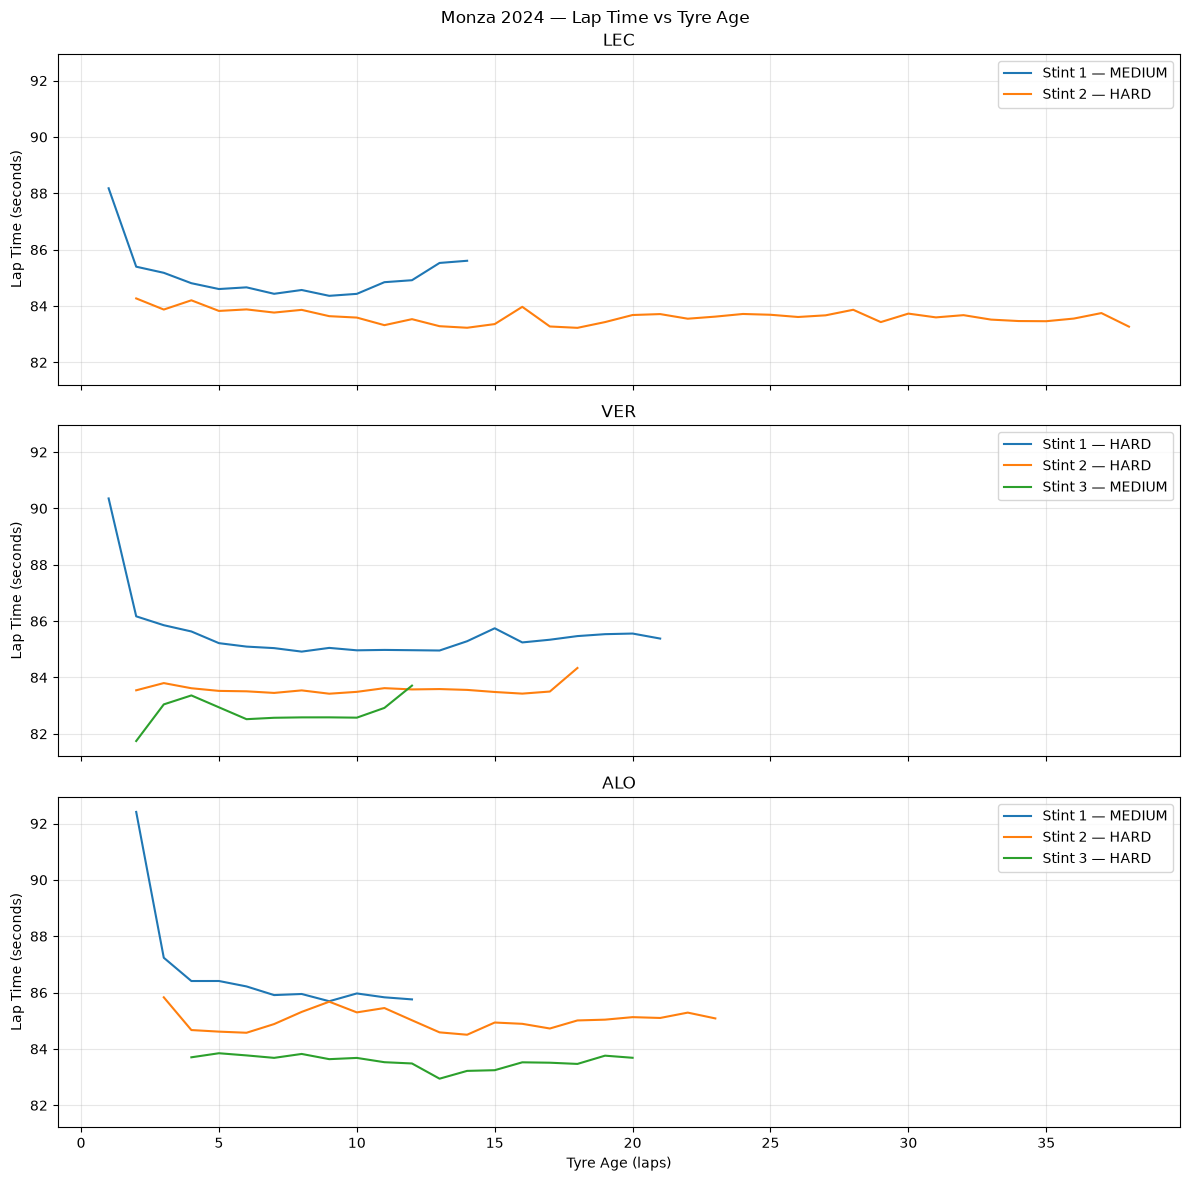

In [8]:
drivers = ["LEC", "VER", "ALO"]

fig, axes = plt.subplots(
    3, 1, figsize=(12, 12), sharex=True, sharey=True
)

for driver, ax in zip(drivers, axes):
    driver_laps = race_laps[
        (race_laps["Driver"] == driver)
        & race_laps["PitInTime"].isna()
        & race_laps["PitOutTime"].isna()
    ]

    for stint, stint_laps in driver_laps.groupby("Stint"):
        compound = stint_laps["Compound"].iloc[0]

        ax.plot(
            stint_laps["TyreLife"],
            stint_laps["LapTimeSeconds"],
            color=f"C{int(stint) - 1}",
            label=f"Stint {int(stint)} — {compound}"
        )

    ax.set_title(driver)
    ax.set_ylabel("Lap Time (seconds)")
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Tyre Age (laps)")
fig.suptitle("Monza 2024 — Lap Time vs Tyre Age")
plt.tight_layout()
plt.show()

Observations:
Laps tend do be faster through the end of the race, as track is hotter and car is lighter. We do not have data to prove this, so this is the only possible general assumption for this project.

Update: the graph below shows the track cooled; the fuel explanation remains untested.

## Temperature of track

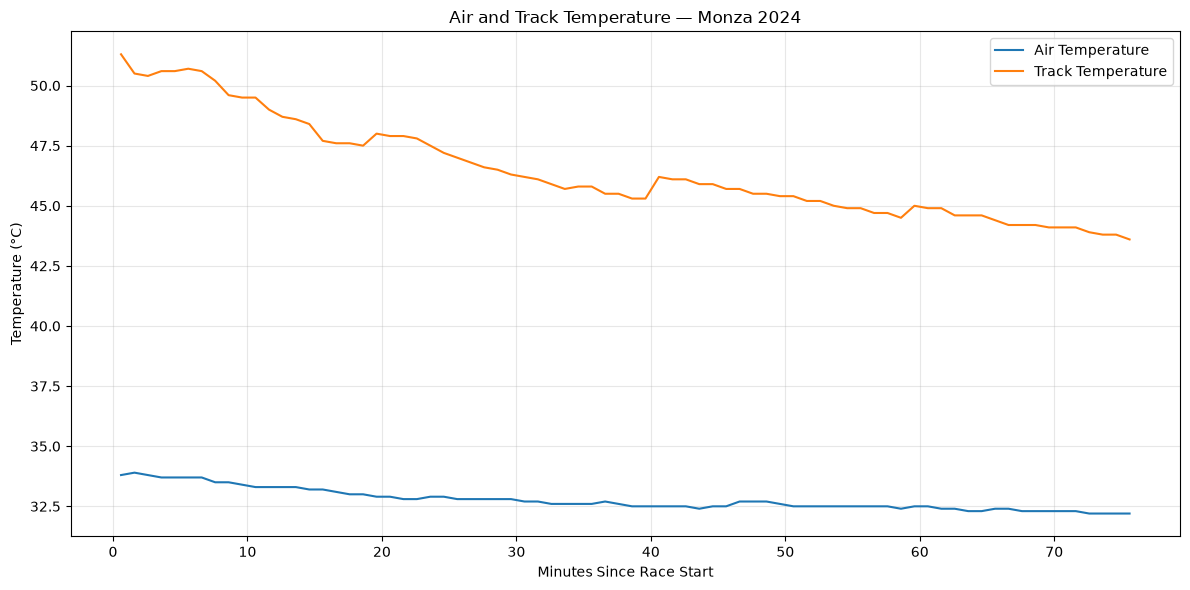

In [9]:
weather = session.weather_data.copy()

race_start = race_laps["LapStartTime"].min()
race_end = race_laps["Time"].max()

weather = weather[
    (weather["Time"] >= race_start)
    & (weather["Time"] <= race_end)
].copy()

weather = weather.sort_values("Time")

weather["RaceMinutes"] = (
    weather["Time"] - race_start
).dt.total_seconds() / 60

plt.figure(figsize=(12, 6))

plt.plot(
    weather["RaceMinutes"],
    weather["AirTemp"],
    label="Air Temperature"
)

plt.plot(
    weather["RaceMinutes"],
    weather["TrackTemp"],
    label="Track Temperature"
)

plt.xlabel("Minutes Since Race Start")
plt.ylabel("Temperature (°C)")
plt.title("Air and Track Temperature — Monza 2024")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Observations:
Track temperature fell from about 51°C to 44°C, while air temperature fell from 34°C to 32°C.

## Compound Comparison Times

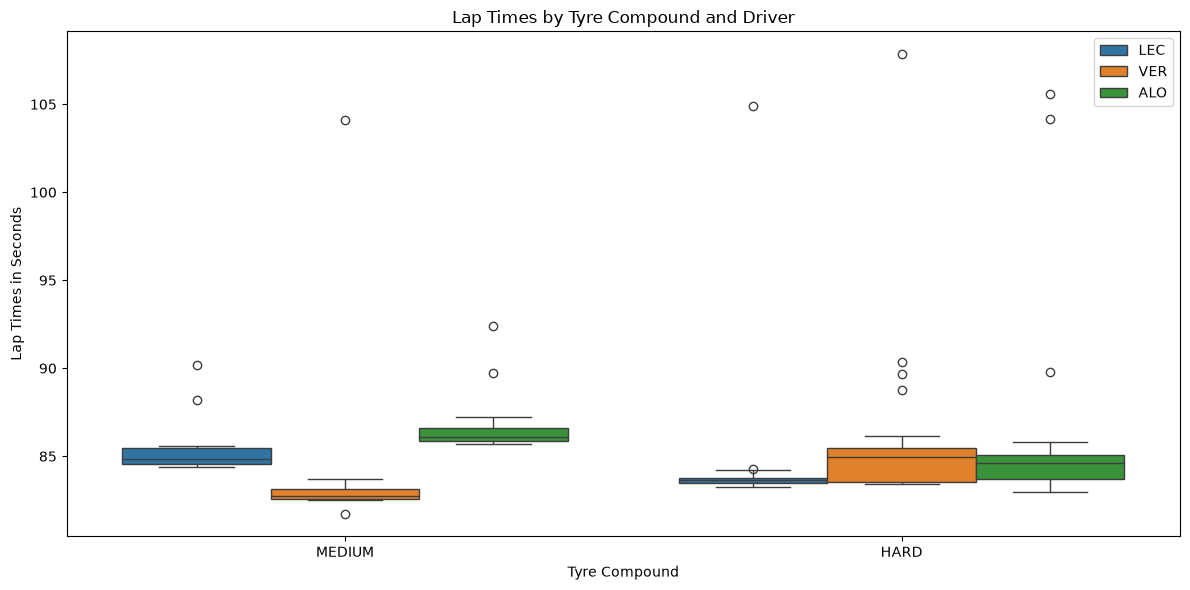

In [10]:
drivers=["LEC", "VER", "ALO"]
selected_laps=race_laps[race_laps["Driver"].isin(drivers)]
plt.figure(figsize=(12,6))

sns.boxplot(
    data=selected_laps,
    x="Compound",
    y="LapTimeSeconds",
    hue="Driver",
    order=["MEDIUM","HARD"]
)

plt.xlabel("Tyre Compound")
plt.ylabel("Lap Times in Seconds")
plt.title("Lap Times by Tyre Compound and Driver")
plt.legend()
plt.tight_layout()
plt.show()

As it can be seen, Verstappens' medium tyres laps were faster than everyone else. Of course, it was his second stint and the fuel load and car weight was lower, but the evolution for medium tyres is great. We can also spot some outliers of slow laps. Now this can mean, both safety cars or yellow flag laps or pit laps, so I will check to see what kind of outlier it is.

## Conclusion